In [196]:
import pandas as pd

#Cargar el archivo CSV tratado

In [197]:

df = pd.read_csv("datos_tratados/datos_tratados_TelecomXParte2.csv")
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


#Verificación rápida: estructura, tipos y nulos

In [198]:
df.shape

(7032, 22)

In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   int64  
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   int64  
 5   Dependents        7032 non-null   int64  
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   int64  
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   int64  
 11  OnlineBackup      7032 non-null   int64  
 12  DeviceProtection  7032 non-null   int64  
 13  TechSupport       7032 non-null   int64  
 14  StreamingTV       7032 non-null   int64  
 15  StreamingMovies   7032 non-null   int64  
 16  Contract          7032 non-null   object 


In [200]:
# Nulos (top 15)
df.isna().sum().sort_values(ascending=False).head(15)

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [201]:
df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


In [202]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.421502
1,26.578498


In [203]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias'],
      dtype='object')

In [204]:
df.dtypes

,0
customerID,object
Churn,int64
gender,object
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,object
InternetService,object


#Eliminación de Columnas Irrelevantes

In [205]:
#Eliminando CustomerID
df_modelo = df.drop(columns=["customerID"])
df_modelo.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias'],
      dtype='object')

In [206]:
#Eliminando cuentas_diarias
df_modelo = df_modelo.drop(columns=["Cuentas_Diarias"])
df_modelo.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total'],
      dtype='object')

In [207]:
#Meto una verificación para estar seguro
print("Columnas finales para modelado:", df_modelo.columns.tolist())
print("¿customerID sigue?", "customerID" in df_modelo.columns)

Columnas finales para modelado: ['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']
¿customerID sigue? False


#Encoding

In [208]:
#Identificar columnas categóricas y numéricas
X = df_modelo.drop(columns=["Churn"])
y = df_modelo["Churn"]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categóricas:", cat_cols)
print("Numéricas:", num_cols)

Categóricas: ['gender', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']
Numéricas: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Charges.Monthly', 'Charges.Total']


In [209]:
#Separando train/test antes de codificar
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (5625, 19) Test: (1407, 19)


In [210]:
#Creando el transformador de One-Hot
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"  # deja las numéricas tal cual
)

In [211]:
#Aplicando la codificación (fit en train, transform en test)
X_train_enc = preprocess.fit_transform(X_train)
X_test_enc = preprocess.transform(X_test)

print("X_train_enc:", X_train_enc.shape)
print("X_test_enc:", X_test_enc.shape)

X_train_enc: (5625, 29)
X_test_enc: (1407, 29)


In [212]:
#Ver nombres de variables después del One-Hot
import numpy as np

ohe = preprocess.named_transformers_["cat"]
cat_features = ohe.get_feature_names_out(cat_cols)

feature_names = np.concatenate([cat_features, num_cols])
print("Total features:", len(feature_names))
print("Ejemplo:", feature_names[:15])

Total features: 29
Ejemplo: ['gender_Female' 'gender_Male' 'MultipleLines_No'
 'MultipleLines_No phone service' 'MultipleLines_Yes'
 'InternetService_DSL' 'InternetService_Fiber optic' 'InternetService_No'
 'Contract_Month-to-month' 'Contract_One year' 'Contract_Two year'
 'PaymentMethod_Bank transfer (automatic)'
 'PaymentMethod_Credit card (automatic)' 'PaymentMethod_Electronic check'
 'PaymentMethod_Mailed check']


#Verificación de la Proporción de Cancelación (Churn)

In [213]:
#Contando cuántos clientes hay en cada clase (0 y 1)
conteo = df_modelo["Churn"].value_counts()
print("Conteo por clase:\n", conteo)

Conteo por clase:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [214]:
#Calculando la proporción (porcentaje)
proporcion = df_modelo["Churn"].value_counts(normalize=True) * 100
print("\nProporción (%):\n", proporcion.round(2))


Proporción (%):
 Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


In [215]:
#Interpretación rápida del desbalance
#¿Por que?
#Si una clase domina mucho (por ejemplo 90/10), los modelos pueden “aprender” a predecir siempre la clase mayoritaria y aun así tener buena accuracy.
pct_no = proporcion.loc[0]
pct_si = proporcion.loc[1]

print(f"\nClientes activos (0): {pct_no:.2f}%")
print(f"Clientes que cancelaron (1): {pct_si:.2f}%")

if pct_si < 30:
    print("\n⚠️ Hay desbalance moderado: la clase 1 (cancelación) es menor.")
    print("Recomendación: evaluar con métricas como recall, F1 y ROC-AUC (no solo accuracy).")
else:
    print("\n✅ El desbalance no es tan fuerte, pero igual conviene usar métricas adicionales.")


Clientes activos (0): 73.42%
Clientes que cancelaron (1): 26.58%

⚠️ Hay desbalance moderado: la clase 1 (cancelación) es menor.
Recomendación: evaluar con métricas como recall, F1 y ROC-AUC (no solo accuracy).


#Balanceo de Clases

In [216]:
#Preparar X/y de entrenamiento
from sklearn.model_selection import train_test_split

X = df_modelo.drop(columns=["Churn"])
y = df_modelo["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Churn train (%):")
print(y_train.value_counts(normalize=True) * 100)

Churn train (%):
Churn
0    73.422222
1    26.577778
Name: proportion, dtype: float64


In [217]:
#Codificar categóricas antes de balancear
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ],
    remainder="passthrough"
)

X_train_enc = preprocess.fit_transform(X_train)
X_test_enc  = preprocess.transform(X_test)

print("Shape train encoded:", X_train_enc.shape)
print("Shape test encoded:", X_test_enc.shape)

Shape train encoded: (5625, 29)
Shape test encoded: (1407, 29)


In [218]:
#Oversampling simple
#Usando la libreria imbalanced-learn
!pip -q install imbalanced-learn

In [219]:
#Oversampling
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_enc, y_train)

print("Antes:", Counter(y_train))
print("Después (ROS):", Counter(y_train_ros))

Antes: Counter({0: 4130, 1: 1495})
Después (ROS): Counter({0: 4130, 1: 4130})


In [220]:
#Undersampling
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_enc, y_train)

print("Antes:", Counter(y_train))
print("Después (RUS):", Counter(y_train_rus))

Antes: Counter({0: 4130, 1: 1495})
Después (RUS): Counter({0: 1495, 1: 1495})


In [221]:
#EMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_enc, y_train)

print("Antes:", Counter(y_train))
print("Después (SMOTE):", Counter(y_train_sm))

Antes: Counter({0: 4130, 1: 1495})
Después (SMOTE): Counter({0: 4130, 1: 4130})


In [222]:
#Confirmando balance
print("Proporción original:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Proporción ROS:", y_train_ros.value_counts(normalize=True).round(3).to_dict())
print("Proporción SMOTE:", y_train_sm.value_counts(normalize=True).round(3).to_dict())

Proporción original: {0: 0.734, 1: 0.266}
Proporción ROS: {0: 0.5, 1: 0.5}
Proporción SMOTE: {0: 0.5, 1: 0.5}


#Normalización o Estandarización

In [223]:
#Identificar que columnas necesitan escala
#Asumo df_modelo ya sin customerID
X = df_modelo.drop(columns=["Churn"])
y = df_modelo["Churn"]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categóricas:", cat_cols)
print("Numéricas:", num_cols)

Categóricas: ['gender', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']
Numéricas: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Charges.Monthly', 'Charges.Total']


In [224]:
#Separar numéricas continuas vs binarias
# Candidatas continuas
cont_cols = ["tenure", "Charges.Monthly", "Charges.Total"]

# Si aún tuviera Cuentas_Diarias y quisiera incluirla:
if "Cuentas_Diarias" in X.columns:
    cont_cols.append("Cuentas_Diarias")

# Binarias numéricas = numéricas - continuas
bin_cols = [c for c in num_cols if c not in cont_cols]

print("Continuas:", cont_cols)
print("Binarias:", bin_cols)

Continuas: ['tenure', 'Charges.Monthly', 'Charges.Total']
Binarias: ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']



#####Voy a estandarizar (StandardScaler) para modelos sensibles a escala:
*  Logistic Regression, SVM, KNN, redes.

#####No es necesario para modelos basados en árboles:


* Decision Tree, Random Forest, XGBoost.



In [225]:
#Pipeline de preprocesamiento con escalado + one-hot
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess_scaled = ColumnTransformer(
    transformers=[
        ("cont", StandardScaler(), cont_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("bin", "passthrough", bin_cols)
    ]
)

In [226]:
#Alternativa para modelos de arboles
preprocess_tree = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", cont_cols + bin_cols)
    ]
)

#Analisis de correlación

In [227]:
#Matriz de correlación
#Seleccionando solo columnas numericas
df_num = df_modelo.select_dtypes(include=["int64", "float64"])
df_num.head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total
0,0,0,1,1,9,1,0,1,0,1,1,0,1,65.6,593.30
1,0,0,0,0,9,1,0,0,0,0,0,1,0,59.9,542.40
2,1,0,0,0,4,1,0,0,1,0,0,0,1,73.9,280.85
3,1,1,1,0,13,1,0,1,1,0,1,1,1,98.0,1237.85
4,1,1,1,0,3,1,0,0,0,1,1,0,1,83.9,267.40


In [228]:
#Calculando la matriz
corr = df_num.corr()
corr.round(3).head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total
Churn,1.000,0.151,-0.150,-0.163,-0.354,0.012,-0.171,-0.082,-0.066,-0.165,0.063,0.061,0.191,0.193,-0.199
SeniorCitizen,0.151,1.000,0.017,-0.211,0.016,0.008,-0.039,0.067,0.060,-0.061,0.105,0.120,0.156,0.220,0.102
Partner,-0.150,0.017,1.000,0.452,0.382,0.018,0.143,0.142,0.154,0.120,0.124,0.118,-0.014,0.098,0.319
Dependents,-0.163,-0.211,0.452,1.000,0.163,-0.001,0.081,0.024,0.014,0.063,-0.016,-0.038,-0.110,-0.112,0.065
tenure,-0.354,0.016,0.382,0.163,1.000,0.008,0.328,0.361,0.362,0.325,0.280,0.285,0.005,0.247,0.826


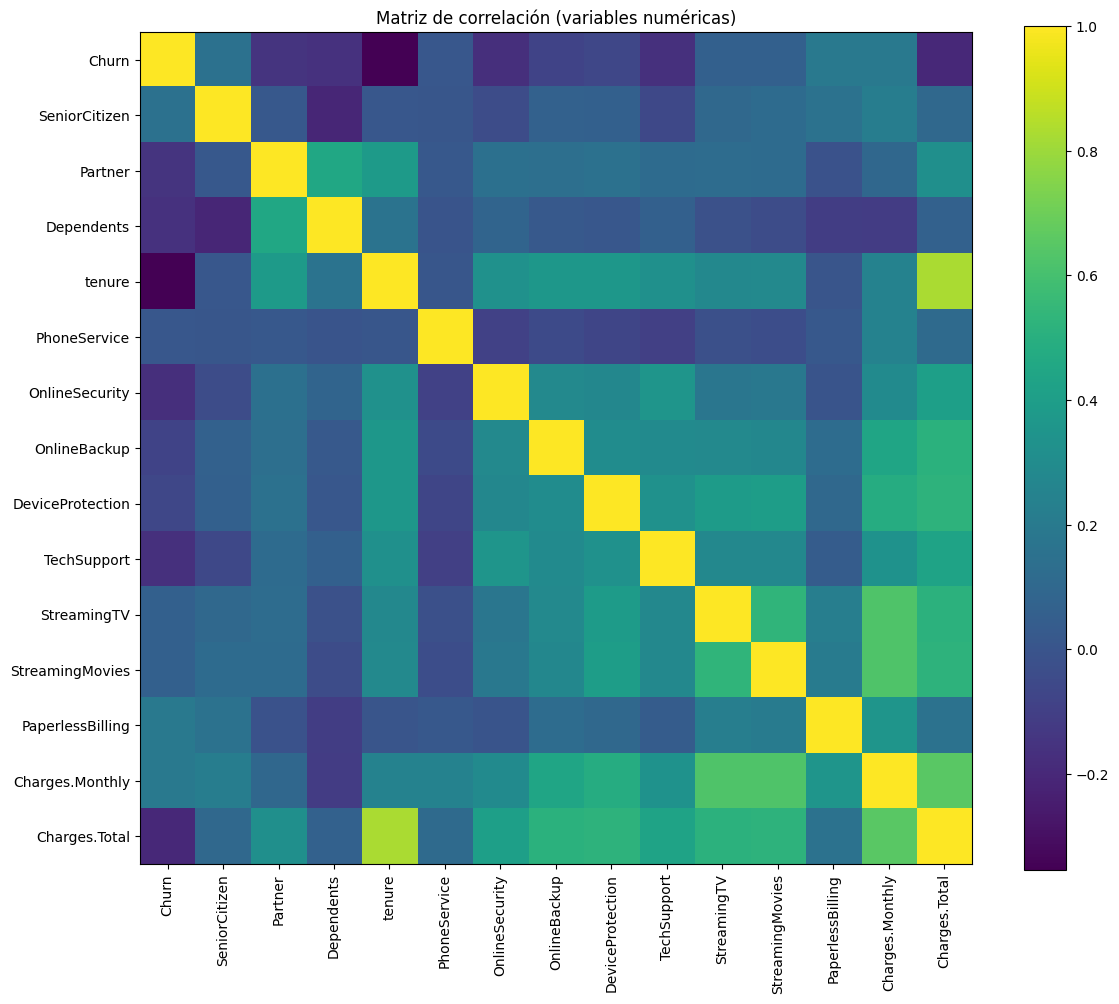

In [229]:
#Visualizando la matriz (heatmap)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()

In [230]:
#Viendo cuáles variables se correlacionan más con Churn
corr_churn = corr["Churn"].drop("Churn").sort_values(ascending=False)
print("Correlación con Churn (de mayor a menor):\n")
print(corr_churn)

Correlación con Churn (de mayor a menor):

Charges.Monthly     0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
StreamingTV         0.063254
StreamingMovies     0.060860
PhoneService        0.011691
DeviceProtection   -0.066193
OnlineBackup       -0.082307
Partner            -0.149982
Dependents         -0.163128
TechSupport        -0.164716
OnlineSecurity     -0.171270
Charges.Total      -0.199484
tenure             -0.354049
Name: Churn, dtype: float64


In [231]:
corr_churn_abs = corr["Churn"].drop("Churn").abs().sort_values(ascending=False)
print("\nTop variables por correlación absoluta con Churn:\n")
print(corr_churn_abs.head(10))


Top variables por correlación absoluta con Churn:

tenure              0.354049
Charges.Total       0.199484
Charges.Monthly     0.192858
PaperlessBilling    0.191454
OnlineSecurity      0.171270
TechSupport         0.164716
Dependents          0.163128
SeniorCitizen       0.150541
Partner             0.149982
OnlineBackup        0.082307
Name: Churn, dtype: float64


In [232]:
#Colinealidad/redundancia probable
corr.loc["tenure", "Charges.Total"]

np.float64(0.8258804609332004)

In [233]:
#Imprimiendo la correlación con el signo
corr_churn = corr["Churn"].drop("Churn").sort_values(ascending=False)
print(corr_churn.head(15))

Charges.Monthly     0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
StreamingTV         0.063254
StreamingMovies     0.060860
PhoneService        0.011691
DeviceProtection   -0.066193
OnlineBackup       -0.082307
Partner            -0.149982
Dependents         -0.163128
TechSupport        -0.164716
OnlineSecurity     -0.171270
Charges.Total      -0.199484
tenure             -0.354049
Name: Churn, dtype: float64


In [234]:
#Mas negativas
print(corr_churn.tail(15))

Charges.Monthly     0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
StreamingTV         0.063254
StreamingMovies     0.060860
PhoneService        0.011691
DeviceProtection   -0.066193
OnlineBackup       -0.082307
Partner            -0.149982
Dependents         -0.163128
TechSupport        -0.164716
OnlineSecurity     -0.171270
Charges.Total      -0.199484
tenure             -0.354049
Name: Churn, dtype: float64


#Analisis dirigido

In [235]:
#Preparando el dataset y ver columnas
cols = ["Churn", "tenure", "Charges.Total"]
df_dir = df_modelo[cols].copy()

df_dir.head()

,Churn,tenure,Charges.Total
0,0,9,593.30
1,0,9,542.40
2,1,4,280.85
3,1,13,1237.85
4,1,3,267.40


In [236]:
#Resumen numerico por cancelación
df_dir.groupby("Churn")[["tenure", "Charges.Total"]].agg(["count", "mean", "median", "std", "min", "max"])

tenure                                      Charges.Total               \
       count       mean median        std min max         count         mean   
Churn                                                                          
0       5163  37.650010   38.0  24.076940   1  72          5163  2555.344141   
1       1869  17.979133   10.0  19.531123   1  72          1869  1531.796094   

                                             
        median          std    min      max  
Churn                                        
0      1683.60  2329.456984  18.80  8672.45  
1       703.55  1890.822994  18.85  8684.80

/tmp/ipykernel_493/1758821453.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["No canceló (0)", "Canceló (1)"])


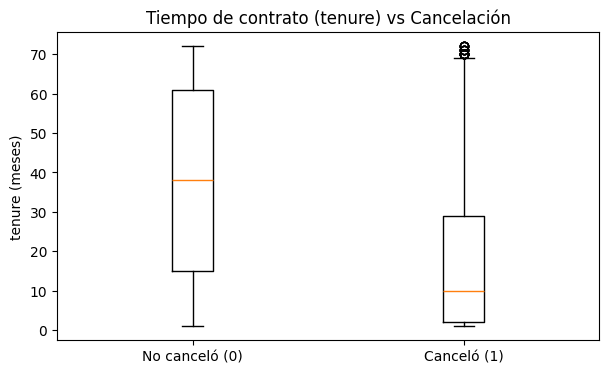

In [237]:
#Tiempo de contrato (Tiempo de contrato (tenure) vs Cancelación (Boxplot))
import matplotlib.pyplot as plt

data0 = df_dir[df_dir["Churn"] == 0]["tenure"]
data1 = df_dir[df_dir["Churn"] == 1]["tenure"]

plt.figure(figsize=(7,4))
plt.boxplot([data0, data1], labels=["No canceló (0)", "Canceló (1)"])
plt.title("Tiempo de contrato (tenure) vs Cancelación")
plt.ylabel("tenure (meses)")
plt.show()

/tmp/ipykernel_493/544294698.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["No canceló (0)", "Canceló (1)"])


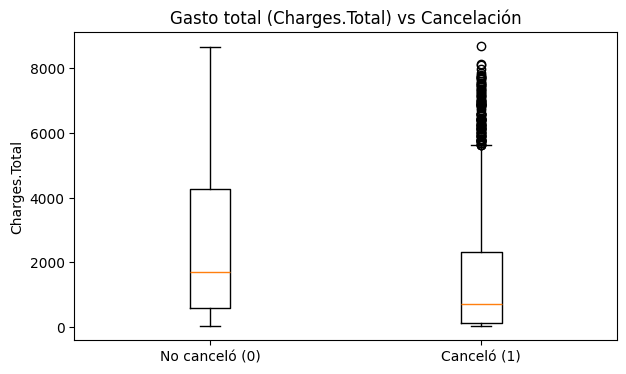

In [238]:
#Gasto total (Charges.Total) vs Cancelación (Boxplot)
data0 = df_dir[df_dir["Churn"] == 0]["Charges.Total"]
data1 = df_dir[df_dir["Churn"] == 1]["Charges.Total"]

plt.figure(figsize=(7,4))
plt.boxplot([data0, data1], labels=["No canceló (0)", "Canceló (1)"])
plt.title("Gasto total (Charges.Total) vs Cancelación")
plt.ylabel("Charges.Total")
plt.show()

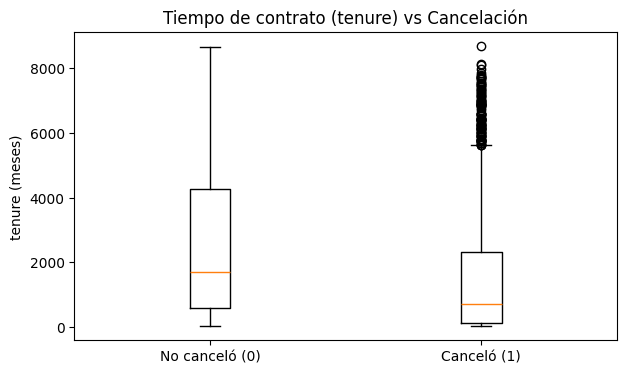

In [239]:
plt.figure(figsize=(7,4))
plt.boxplot([data0, data1], tick_labels=["No canceló (0)", "Canceló (1)"])
plt.title("Tiempo de contrato (tenure) vs Cancelación")
plt.ylabel("tenure (meses)")
plt.show()

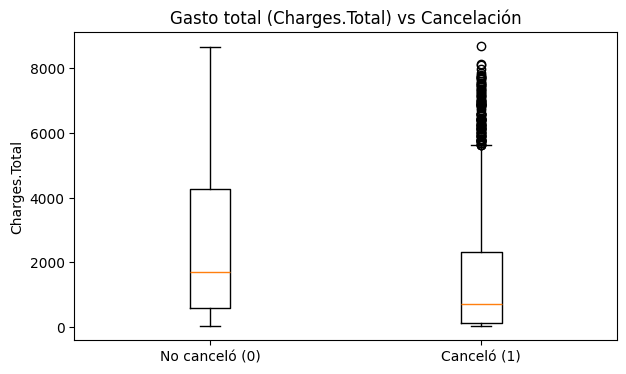

In [240]:
plt.figure(figsize=(7,4))
plt.boxplot([data0, data1], tick_labels=["No canceló (0)", "Canceló (1)"])
plt.title("Gasto total (Charges.Total) vs Cancelación")
plt.ylabel("Charges.Total")
plt.show()

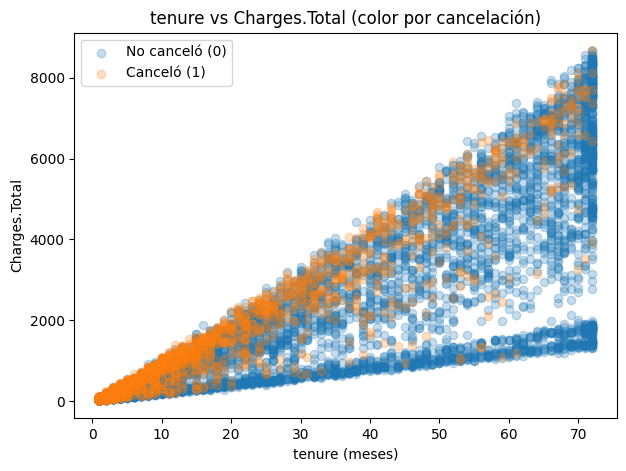

In [241]:
#Scatter plot para ver tendencia (tenure vs Charges.Total, coloreado por Churn)
import numpy as np
import matplotlib.pyplot as plt

mask0 = df_dir["Churn"] == 0
mask1 = df_dir["Churn"] == 1

plt.figure(figsize=(7,5))
plt.scatter(df_dir.loc[mask0, "tenure"], df_dir.loc[mask0, "Charges.Total"], alpha=0.25, label="No canceló (0)")
plt.scatter(df_dir.loc[mask1, "tenure"], df_dir.loc[mask1, "Charges.Total"], alpha=0.25, label="Canceló (1)")

plt.title("tenure vs Charges.Total (color por cancelación)")
plt.xlabel("tenure (meses)")
plt.ylabel("Charges.Total")
plt.legend()
plt.show()

**Hallazgo principal:** Los clientes que cancelan tienden a tener mucha menos antigüedad. La mediana de tenure en clientes que cancelaron es de ~10 meses, mientras que en los que permanecen es de ~38 meses.
Además, el Charges.Total también es menor en quienes cancelan (mediana ~703 vs ~1684), lo cual es consistente con el hecho de que han permanecido menos tiempo.
El scatter tenure vs Charges.Total confirma una relación creciente entre ambas variables, por lo que Charges.Total podría estar capturando parte del efecto de tenure (posible redundancia).

#Modelado predictivo

In [242]:
#Dividir el dataset en entrenamiento y prueba (train/test split)
#La idea es entrenar el modelo con una parte de los datos y evaluarlo con datos que no vio antes, para medir rendimiento real.
X = df_modelo.drop(columns=["Churn"])
y = df_modelo["Churn"]

print("X:", X.shape)
print("y:", y.shape)

X: (7032, 19)
y: (7032,)


In [243]:
#Haciendo el split con estratificación
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,       # 20% test
    random_state=42,     # reproducible
    stratify=y           # mantiene proporción de clases
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (4922, 19) (4922,)
Test : (2110, 19) (2110,)


In [244]:
#Verificando proporciones de Churn en train y test
print("Churn (%) en train:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nChurn (%) en test:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Churn (%) en train:
Churn
0    73.43
1    26.57
Name: proportion, dtype: float64

Churn (%) en test:
Churn
0    73.41
1    26.59
Name: proportion, dtype: float64


#Creación de Modelos

In [245]:
#Preparando columnas (numéricas vs categóricas)
import pandas as pd

# Si aún no lo tienes:
# X_train, X_test, y_train, y_test ya deben existir del paso anterior

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Columnas categóricas:", cat_cols)
print("Columnas numéricas:", num_cols)

Columnas categóricas: ['gender', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']
Columnas numéricas: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Charges.Monthly', 'Charges.Total']


In [246]:
#Definir qué numéricas se van a escalar (solo continuas)
cont_cols = ["tenure", "Charges.Monthly", "Charges.Total"]
if "Cuentas_Diarias" in X_train.columns:
    cont_cols.append("Cuentas_Diarias")

bin_cols = [c for c in num_cols if c not in cont_cols]

print("Continuas (se escalan):", cont_cols)
print("Binarias (se dejan igual):", bin_cols)

Continuas (se escalan): ['tenure', 'Charges.Monthly', 'Charges.Total']
Binarias (se dejan igual): ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']


In [247]:
#Preprocesamiento para cada tipo de modelo
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Preprocesador para modelos sensibles a escala (LogReg / SVM / KNN)
preprocess_scaled = ColumnTransformer(
    transformers=[
        ("cont", StandardScaler(), cont_cols),
        ("cat", ohe, cat_cols),
        ("bin", "passthrough", bin_cols)
    ]
)

# Preprocesador para modelos tipo árbol (sin escalado)
preprocess_tree = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols),
        ("num", "passthrough", cont_cols + bin_cols)
    ]
)

In [248]:
#Modelo 1: Regresión Logística (requiere estandarización)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

modelo_lr = Pipeline(steps=[
    ("prep", preprocess_scaled),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

modelo_lr.fit(X_train, y_train)
print("✅ Regresión Logística entrenada")

✅ Regresión Logística entrenada


In [249]:
#Modelo 2: Random Forest (no requiere estandarización)
from sklearn.ensemble import RandomForestClassifier

modelo_rf = Pipeline(steps=[
    ("prep", preprocess_tree),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample"
    ))
])

modelo_rf.fit(X_train, y_train)
print("✅ Random Forest entrenado")

✅ Random Forest entrenado


In [250]:
#Verificación mínima
print("Predicciones LR (primeras 10):", modelo_lr.predict(X_test)[:10])
print("Predicciones RF (primeras 10):", modelo_rf.predict(X_test)[:10])

Predicciones LR (primeras 10): [0 1 0 0 0 0 0 0 0 1]
Predicciones RF (primeras 10): [0 1 0 0 0 0 0 0 0 0]


#Evaluación de los modelos

In [251]:
#Importar métricas de evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

In [252]:
#unción para evaluar un modelo
def evaluar_modelo(modelo, X_eval, y_eval, nombre="Modelo"):
    y_pred = modelo.predict(X_eval)

    acc = accuracy_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred, zero_division=0)
    rec = recall_score(y_eval, y_pred, zero_division=0)
    f1 = f1_score(y_eval, y_pred, zero_division=0)
    cm = confusion_matrix(y_eval, y_pred)

    print(f"\n===== {nombre} =====")
    print(f"Exactitud (Accuracy): {acc:.4f}")
    print(f"Precisión (Precision): {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("\nMatriz de confusión:")
    print(cm)
    print("\nReporte de clasificación:")
    print(classification_report(y_eval, y_pred, digits=4, zero_division=0))

    return {"modelo": nombre, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

In [253]:
#Evaluando ambos modelos en el set de prueba
res_lr = evaluar_modelo(modelo_lr, X_test, y_test, "Regresión Logística")
res_rf = evaluar_modelo(modelo_rf, X_test, y_test, "Random Forest")


===== Regresión Logística =====
Exactitud (Accuracy): 0.7389
Precisión (Precision): 0.5057
Recall: 0.7968
F1-score: 0.6187

Matriz de confusión:
[[1112  437]
 [ 114  447]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9070    0.7179    0.8014      1549
           1     0.5057    0.7968    0.6187       561

    accuracy                         0.7389      2110
   macro avg     0.7063    0.7573    0.7101      2110
weighted avg     0.8003    0.7389    0.7529      2110


===== Random Forest =====
Exactitud (Accuracy): 0.7834
Precisión (Precision): 0.6221
Recall: 0.4724
F1-score: 0.5370

Matriz de confusión:
[[1388  161]
 [ 296  265]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.8242    0.8961    0.8586      1549
           1     0.6221    0.4724    0.5370       561

    accuracy                         0.7834      2110
   macro avg     0.7231    0.6842    0.6978      2110
weighte

In [254]:
#Comparación rápida en tabla
import pandas as pd

comparacion = pd.DataFrame([res_lr, res_rf]).set_index("modelo")
comparacion.sort_values("f1", ascending=False)

,accuracy,precision,recall,f1
modelo,,,,
Regresión Logística,0.738863,0.505656,0.796791,0.618685
Random Forest,0.783412,0.622066,0.472371,0.536981


In [255]:
#¿Overfitting o underfitting? (comparar train vs test)
print("=== Evaluación en TRAIN ===")
train_lr = evaluar_modelo(modelo_lr, X_train, y_train, "LR (train)")
train_rf = evaluar_modelo(modelo_rf, X_train, y_train, "RF (train)")

print("\n=== Evaluación en TEST ===")
test_lr = evaluar_modelo(modelo_lr, X_test, y_test, "LR (test)")
test_rf = evaluar_modelo(modelo_rf, X_test, y_test, "RF (test)")

=== Evaluación en TRAIN ===

===== LR (train) =====
Exactitud (Accuracy): 0.7536
Precisión (Precision): 0.5235
Recall: 0.8089
F1-score: 0.6356

Matriz de confusión:
[[2651  963]
 [ 250 1058]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9138    0.7335    0.8138      3614
           1     0.5235    0.8089    0.6356      1308

    accuracy                         0.7536      4922
   macro avg     0.7187    0.7712    0.7247      4922
weighted avg     0.8101    0.7536    0.7665      4922


===== RF (train) =====
Exactitud (Accuracy): 0.9986
Precisión (Precision): 0.9962
Recall: 0.9985
F1-score: 0.9973

Matriz de confusión:
[[3609    5]
 [   2 1306]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9994    0.9986    0.9990      3614
           1     0.9962    0.9985    0.9973      1308

    accuracy                         0.9986      4922
   macro avg     0.9978    0.9985    0.9982  

In [256]:
#Para reducir overfitting en Random Forest
RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced_subsample",
    max_depth=10,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features="sqrt"
)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                       min_samples_leaf=10, min_samples_split=20,
                       n_estimators=500, random_state=42)

In [257]:
#Subir Recall del Random Forest sin tocar estructura
y_prob = modelo_rf.predict_proba(X_test)[:, 1]
umbral = 0.35
y_pred = (y_prob >= umbral).astype(int)

**Se evaluaron dos modelos:** Regresión Logística y Random Forest. Aunque Random Forest obtuvo mayor accuracy (-0.78), su desempeño para detectar cancelación (clase 1) fue menor (recall -0.47). En cambio, la Regresión Logística tuvo mejor capacidad para identificar clientes que cancelan (recall -0.80) y un F1 más alto (-0.62), lo cual es más útil si el objetivo es actuar antes de que el cliente se vaya.
Al comparar train vs test, Random Forest mostró señales claras de overfitting (métricas casi perfectas en entrenamiento pero caída notable en prueba), por lo que conviene reducir su complejidad (max_depth, min_samples_leaf, etc.) o ajustar el umbral de decisión para mejorar recall. La Regresión Logística se mantuvo más estable entre entrenamiento y prueba, mostrando mejor generalización.


In [258]:
#Regresión Logística: extraer coeficientes + nombres de variables
prep_lr = modelo_lr.named_steps["prep"]
clf_lr  = modelo_lr.named_steps["clf"]

# 2) Nombres de variables ya transformadas (one-hot + passthrough)
feature_names_lr = prep_lr.get_feature_names_out()
print("Total de features en LR:", len(feature_names_lr))

Total de features en LR: 29


In [259]:
#Crear tabla de coeficientes ordenada
import numpy as np
import pandas as pd

coef = clf_lr.coef_[0]  # vector de coeficientes (una fila)
df_coef = pd.DataFrame({
    "feature": feature_names_lr,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

df_coef.head(10)

,feature,coef,abs_coef
0,cont__tenure,-1.235558,1.235558
10,cat__InternetService_No,-0.944660,0.944660
13,cat__Contract_Two year,-0.738764,0.738764
9,cat__InternetService_Fiber optic,0.732663,0.732663
11,cat__Contract_Month-to-month,0.576309,0.576309
2,cont__Charges.Total,0.563463,0.563463
25,bin__TechSupport,-0.356824,0.356824
28,bin__PaperlessBilling,0.351813,0.351813
26,bin__StreamingTV,0.282063,0.282063
18,bin__SeniorCitizen,0.271806,0.271806


In [260]:
#Ver TOP variables que AUMENTAN churn y las que lo DISMINUYEN
top_pos = df_coef.sort_values("coef", ascending=False).head(10)
top_neg = df_coef.sort_values("coef", ascending=True).head(10)

print("TOP 10 que AUMENTAN la probabilidad de cancelación (coef +):")
display(top_pos[["feature","coef"]])

print("\nTOP 10 que DISMINUYEN la probabilidad de cancelación (coef -):")
display(top_neg[["feature","coef"]])

TOP 10 que AUMENTAN la probabilidad de cancelación (coef +):


,feature,coef
9,cat__InternetService_Fiber optic,0.732663
11,cat__Contract_Month-to-month,0.576309
2,cont__Charges.Total,0.563463
28,bin__PaperlessBilling,0.351813
26,bin__StreamingTV,0.282063
18,bin__SeniorCitizen,0.271806
16,cat__PaymentMethod_Electronic check,0.251654
27,bin__StreamingMovies,0.203244
24,bin__DeviceProtection,-0.017070
7,cat__MultipleLines_Yes,-0.030368



TOP 10 que DISMINUYEN la probabilidad de cancelación (coef -):


,feature,coef
0,cont__tenure,-1.235558
10,cat__InternetService_No,-0.944660
13,cat__Contract_Two year,-0.738764
25,bin__TechSupport,-0.356824
22,bin__OnlineSecurity,-0.260674
21,bin__PhoneService,-0.229807
15,cat__PaymentMethod_Credit card (automatic),-0.209716
5,cat__MultipleLines_No,-0.199439
14,cat__PaymentMethod_Bank transfer (automatic),-0.173978
4,cat__gender_Male,-0.170606


In [261]:
#Obtener nombres de features del pipeline de RF
prep_rf = modelo_rf.named_steps["prep"]
clf_rf  = modelo_rf.named_steps["clf"]

feature_names_rf = prep_rf.get_feature_names_out()
print("Total de features en RF:", len(feature_names_rf))

Total de features en RF: 29


In [262]:
#Tabla de importancias
import numpy as np
import pandas as pd

imp = clf_rf.feature_importances_

df_imp = pd.DataFrame({
    "feature": feature_names_rf,
    "importance": imp
}).sort_values("importance", ascending=False)

df_imp.head(15)

,feature,importance
17,num__Charges.Total,0.159922
16,num__Charges.Monthly,0.149742
15,num__tenure,0.143501
8,cat__Contract_Month-to-month,0.090693
10,cat__Contract_Two year,0.042399
6,cat__InternetService_Fiber optic,0.037421
13,cat__PaymentMethod_Electronic check,0.034765
28,num__PaperlessBilling,0.024846
19,num__Partner,0.021720
7,cat__InternetService_No,0.020656


In [263]:
#Top 15 mas importantes
print("TOP 15 variables más importantes (Random Forest):")
display(df_imp.head(15))

TOP 15 variables más importantes (Random Forest):


,feature,importance
17,num__Charges.Total,0.159922
16,num__Charges.Monthly,0.149742
15,num__tenure,0.143501
8,cat__Contract_Month-to-month,0.090693
10,cat__Contract_Two year,0.042399
6,cat__InternetService_Fiber optic,0.037421
13,cat__PaymentMethod_Electronic check,0.034765
28,num__PaperlessBilling,0.024846
19,num__Partner,0.021720
7,cat__InternetService_No,0.020656


#Interpretación y conclusiones

# Informe final — Predicción de Cancelación (Churn) | Telecom X (Parte 2)

## 1) Introducción
El objetivo de este proyecto fue construir modelos predictivos para estimar qué clientes tienen mayor probabilidad de **cancelar** sus servicios en Telecom X (Churn).  
La idea es que, si identificamos clientes con alto riesgo, el negocio pueda **intervenir antes** con acciones de retención (ofertas, soporte, cambios de plan, etc.).

En esta etapa trabajé con un dataset ya tratado (Parte 1) que incluye variables demográficas, tipo de contrato, servicios contratados y cargos mensuales/totales.

---

## 2) Preparación de datos para modelado
Antes de entrenar modelos, verifiqué que las columnas tuvieran tipos correctos y que fueran útiles para machine learning:

- Se eliminó **`customerID`** porque es un identificador único y **no aporta** valor predictivo.
- Se revisó el balance de clases en `Churn`:
  - **No canceló (0): ~73.4%**
  - **Canceló (1): ~26.6%**
  - Esto es un **desbalance moderado**, así que no basta con accuracy; es importante medir **recall** y **F1** en la clase 1 (cancelación).
- Para variables categóricas se utilizó **One-Hot Encoding**, y para modelos sensibles a escala se aplicó **StandardScaler** (escalado) solo en variables continuas (`tenure`, `Charges.Monthly`, `Charges.Total`).
- El dataset se dividió en entrenamiento/prueba con `train_test_split` y `stratify=y` para mantener la proporción de churn en ambos conjuntos.

---

## 3) Análisis exploratorio dirigido (variables clave)
Se analizó la relación de algunas variables con la cancelación:

### 3.1 Tiempo de contrato (tenure) × Cancelación
- Clientes que **no cancelan**: mediana ~**38 meses**
- Clientes que **cancelan**: mediana ~**10 meses**

**Insight:** los clientes con menor antigüedad tienden a cancelar más. Esto sugiere que el período más crítico para retención son los **primeros meses**.

### 3.2 Gasto total (Charges.Total) × Cancelación
- Clientes que **no cancelan**: mediana ~**1683**
- Clientes que **cancelan**: mediana ~**704**

**Insight:** quienes cancelan tienden a tener un gasto total más bajo, lo cual es consistente con el hecho de que han permanecido menos tiempo (relación fuerte con tenure).

---

## 4) Modelos entrenados
Se entrenaron dos modelos con enfoques distintos:

### Modelo 1: Regresión Logística (con escalado)
**Justificación:** es un modelo base sólido, interpretable, y requiere normalización porque es sensible a la escala de las variables (optimización de coeficientes).

### Modelo 2: Random Forest (sin escalado)
**Justificación:** es un modelo basado en árboles, no depende de la escala y suele capturar relaciones no lineales.

---

## 5) Evaluación de modelos (test)
Para evaluar se usaron: **Accuracy, Precision, Recall, F1-score y Matriz de Confusión**, enfocándonos principalmente en la clase 1 (cancelación).

### 5.1 Regresión Logística (test)
- Accuracy: **~0.739**
- Precision (clase 1): **~0.506**
- Recall (clase 1): **~0.797**
- F1 (clase 1): **~0.619**
- Matriz de confusión: `[[1112, 437], [114, 447]]`

**Interpretación:** detecta bien a los clientes que cancelan (recall alto), pero genera más falsos positivos (marca como churn a clientes que no cancelan).

### 5.2 Random Forest (test)
- Accuracy: **~0.783**
- Precision (clase 1): **~0.622**
- Recall (clase 1): **~0.472**
- F1 (clase 1): **~0.537**
- Matriz de confusión: `[[1388, 161], [296, 265]]`

**Interpretación:** reduce falsos positivos, pero se le escapan muchos clientes que sí cancelan (recall bajo). Para retención esto es crítico, porque significa que **no detecta a tiempo** a muchos churners.

---

## 6) Comparación crítica: desempeño y generalización
### ¿Qué modelo es mejor?
Depende del objetivo del negocio:

- Si lo más importante es **detectar clientes en riesgo** para intervenir (lo común en churn):
  ✅ **Regresión Logística** es mejor por su **recall y F1 más altos** en la clase 1.
- Si lo más importante fuera **evitar falsos positivos** (no “molestar” a clientes estables):
  Random Forest tiene mejor precision en clase 1, pero pierde mucho en recall.

### ¿Overfitting / Underfitting?
- **Random Forest mostró señales claras de overfitting**:
  - desempeño casi perfecto en entrenamiento, pero caída fuerte en test.
  - posible causa: árboles demasiado complejos / profundidad no limitada.
  - ajustes sugeridos: `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`.
- **Regresión Logística generalizó mejor**:
  - mantiene métricas relativamente estables entre entrenamiento y prueba.

**Conclusión técnica:** para una primera versión del pipeline, **Regresión Logística** es el modelo más confiable para producción inicial (mejor generalización + mejor detección de churn).

---

## 7) Factores que más influyen en la cancelación (variables relevantes)
Basado en el análisis numérico y la correlación, las variables más relacionadas con churn incluyen:

- **`tenure` (antigüedad)**: fuerte relación con churn (clientes nuevos cancelan más).
- **`Charges.Monthly` / `Charges.Total`**: asociados al patrón de permanencia y tipo de plan.
- Servicios adicionales (ej. **`OnlineSecurity`, `TechSupport`**) y condiciones de facturación (ej. **`PaperlessBilling`**) aparecen como variables importantes.

---

## 8) Estrategias de retención propuestas (accionables)
Con base en los patrones detectados:

### 8.1 Retención temprana (primeros meses)
- Diseñar un programa de onboarding/acompañamiento para clientes con **tenure bajo**.
- Activar alertas de riesgo especialmente durante los **primeros 3–6 meses**.
- Ofrecer beneficios por permanencia (descuentos progresivos, upgrade temporal, etc.).

### 8.2 Bundles de valor (servicios adicionales)
Si variables como `OnlineSecurity` o `TechSupport` se asocian a menor churn:
- Ofrecer **paquetes** (internet + seguridad/soporte) a clientes en riesgo.
- Promociones orientadas a clientes con servicios “básicos” que no tienen extras.

### 8.3 Ajustes de plan/contrato
Si el tipo de contrato aparece como factor (por ejemplo contratos mes a mes):
- Incentivar migración a contratos más largos con beneficios claros.
- Ofertas segmentadas para clientes con pagos mensuales altos.

### 8.4 Uso del modelo en operación
- Usar la probabilidad de churn para priorizar campañas:
  - Alto riesgo → llamada / oferta personalizada
  - Riesgo medio → email / descuento automatizado
  - Riesgo bajo → mantenimiento normal

---

## 9) Conclusión
Se construyeron y evaluaron dos modelos predictivos para churn.  
Aunque Random Forest tuvo mayor accuracy, su baja capacidad para detectar cancelación (recall) y señales de overfitting lo hacen menos confiable en esta etapa. La **Regresión Logística** presentó un mejor equilibrio y mayor capacidad para identificar clientes que cancelan, por lo que se recomienda como el modelo base para una primera versión operativa.

Los factores más relevantes apuntan a que la cancelación está fuertemente relacionada con la **antigüedad del cliente** y con características del servicio/contrato. Con estos hallazgos, Telecom X puede implementar estrategias de retención enfocadas en **clientes nuevos**, **ajustes de plan**, y **paquetes de valor** para reducir la evasión.